In [1]:
import sys
import heapq
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from time import perf_counter


# 1. Introducción.


Dado un conjunto finito $E$, se denota $2^E$ como el conjunto de sus partes. A efectos de la programación, se relacionará $E$ con $\{1, \dots, n\}$. A este conjunto lo denotaremos como $[n]$. Los elementos de $E$ se denotarán con letras minúsculas, y los subconjuntos de $E$, con mayúsculas.

Se llama función de conjuntos a una función $f:2^E \to \mathbb{R}$. Si $i \in E$ y $A \subset E$, se usará la notación $f(i|A) = f(\{i\}\cup A) - f(A)$. Este valor se llama rendimiento marginal.

Se dice que $f$ es monótona creciente si $f(A) \leq f(B)$ siempre que $A \subset B$. Equivalentemente, es marginal si $f(i|A) \geq 0$ para cualesquiera $i, A$.

Se dice que $f$ es submodular si verifica
$$f(A \cup B) + f(A \cap B) \leq f(A) + f(B)$$
para cualesquiera $A, B \subset E$.
Las siguientes condiciones son equivalentes a la submodularidad.
- Para todo $A \subset B$ e $i \notin B$ se cumple $f(i|B) \leq f(i|A)$.
- Para todo $A$ e $i, j \notin A$ se cumple $f(i,j|A) \leq f(i|A) + f(j|A)$.
Por tanto, la submodularidad se conoce como *propiedad de rendimientos decrecientes*.

# 2. El algoritmo greedy

## 2.1. Introducción

Se buscan algoritmos para resolver problemas del tipo
$$ \max \{f(A) : A \subset E, |A| = k\},$$
donde $f$ es submodular. Este problema es NP-difícil en general, así que se requieren algoritmos aproximados. El algoritmo más usual para resolverlo es el algoritmo *greedy* (voraz o míope).
El algoritmo *greedy* consiste en los siguientes pasos:
```
    A(0) = {}
    l = 1       ###  l es el contador
    while (l <= k)
        i(l) = arg max{f(i|A(l-1)) : i \notin A(l-1)}
        A(l) = A(l-1) + i(l)
        l = l+1
```
Este algoritmo no requiere la submodularidad de $f$. De hecho, se usa constantemente de forma heurística, en problemas de elección que aparecen en Estadística, *Machine learing*, etc. La submodularidad de $f$ aporta cotas robustas a la solución *greedy*, así como mejoras computacionales al método.

El siguiente bloque de código contiene una implementación sencilla del algoritmo greedy.

In [2]:
def greedy(f, n, k):
    """
    f - Funcion
    n - Cardinal del conjunto base
    k - Maxima longitud de la lista
    """
    indices = []
    valores = []
    cnt = 0
    while cnt < k:
        cnt += 1
        max_valor = -sys.float_info.max # Cota minima
        max_indice = -1 # Valor nul
        for i in range(n):
            valor_greedy = -sys.float_info.max
            if (i not in indices):
                valor_greedy = f(indices + [i])
                if valor_greedy > max_valor:
                    # En este caso mi valor es mejor:
                    max_indice = i
                    max_valor = valor_greedy
        indices.append(max_indice)
        valores.append(max_valor)
    return indices, valores


## 2.2. La cota de Nemhauser

Cuando la función $f$, además de ser submodular, es monótona creciente y $f(\emptyset) = 0$, esta goza de propiedades adicionales. En particular, se tiene una cota robusta para la solución *greedy*.

**Teorema** (Nemhauser).
Sea $f$ submodular creciente con $f(\emptyset)=0$. Sea $A^*$ la solución óptima del problema $\max \{f(A) : |A| =k\}$ y sea $A_k$ la solución dada por el algoritmo *greedy*. Entonces
$$f(A_k) \geq \left( 1- \frac{1}{e} \right)f(A^*).$$

En la práctica, la solución *greedy* suele ser mucho mejor que la cota que nos proporciona este teorema. Sin embargo, esta cota es óptima, (no existe una mejor cota inferior universal).

## 2.3. El algoritmo *lazy greedy*.

Analizando el algoritmo *greedy*, vemos que en cada iteración se calculan todos los $f(i|S_k)$ se calcula su máximo. Pero sabemos que $f(i|S_{k-1}) \geq f(i|S_k)$.
Puede darse el caso en el que hemos calculado $f(i|S_k)$, no hemos calculado $f(j|S_k)$ pero sabemos que $f(i|S_k) \geq f(j|S_{k-1})$. En este caso se deduce que $f(i|S_k) \geq f(j|S_k)$, por lo que $f(j|S_k)$ no puede ser máximo, y no es necesario calcular $f(S_k \cup \{j\})$.
Este hecho permite redefinir el algoritmo *greedy* para ahorrar evaluaciones de $f$, obteniendo el mismo resultado. El algoritmo resultante es el llamado *lazy greedy*. Es más complejo, puesto que requiere una cola de prioridad, pero reduce muchísimas operaciones.

El algoritmo en pseudo código se expresa a continuacion.
```
Asignar S(0) = {}.
Asignar G como un array de dimensión n.
Para cada i=1,...,n, Asignar G(i) = f({i}).
Para cada k = 1,...,m:
    Bucle (b):
        Asignar i = arg max {G(i): i \notin S(k-1)}.
        Si f(i|S(k-1)) no se ha calculado.
            Asignar G(i) = f(i|S(k-1)).
            Repetir bucle (b).
        Si f(i|S(k-1)) sí se ha calculado:
            Asignar i(k) = i.
            Asignar S(k) = S(k-1) \cup {i(k)}$. 
            Salir del bucle (b).
```

Se ha usado una cola de prioridad (*priority queue* o *heap queue*), que es una estructura de datos que permite añadir valores arbitrarios y eliminar el más grande con eficiencia logarítmica (requiere el paquete `headpq`). La siguiente celda contiene la implementación en Python del *lazy greedy*.


In [3]:
def lazy_greedy(f, n, m):
    A = [] # vector de indices
    f_A = [] # vector de 
    orden = list(range(n))
    f_A_k = f([]) # El último f_A calculado
    ganancia = [(-f([i]) + f_A_k, i) for i in range(n)]
    heapq.heapify(ganancia)

    # ganancia - array de ganancias. Es un array cuyos componentes son duplas (x,i) donde i es el índice.
    # $x=f(i|S_{k})$ cuando se calculó por ultima vez.
    # Se ha convertido en una cola de prioridad (max-heap) (paquete heapq), con el fin de hacer más eficientes la
    # inserción y extracción del valor de maxima prioridad.
    actualizado = list(range(n))
    for k in range(m):
        while True:
            gan0, i0 = heapq.heappop(ganancia)
            if i0 in actualizado:
                break # Este es el i0 que buscamos
            else:
                actualizado.append(i0)
                gan0 = -(f(A+[i0]) - f_A_k)
                heapq.heappush(ganancia, (gan0, i0))
            # Se ha cogido el indice optimo. Actualizo lista.
        A.append(i0)
        f_A.append(-gan0 + f_A_k)

        # Preparo todo para el próximo bucle
        f_A_k = f_A[-1]
        actualizado.clear()
            
    return A, f_A


# 3. Aplicaciones a la estadística

Las funciones submodulares tienen muchas aplicaciones en problemas combinatorios o de elección, que se presentan en diversas áreas de las matemáticas.
Particularmente, en la estadística, surge con frecuencia el problema de seleccionar un subconjunto óptimo de elementos (variables, observaciones, etc) bajo ciertas restricciones de presupuesto o cardinalidad.

## 3.1. Selección de variables.

Se tienen varias variables aleatorias $X_1, \dots, X_p$ y se quieren seleccionar las $k$ variables más significativas.
Se va a suponer que siguen una distribución normal multivariante $(X_1, \dots, X_p) \sim \mathcal{N}_p(\mu, \Sigma)$, siendo $\Sigma$ definida positiva.
Queremos elegir el subconjunto $S \subset [p]$ de cardinal $k$ que maximice $\det \Sigma_S$, donde $\Sigma_S$ es el la submatriz cuadrada de $\Sigma$ que contiene sólo las variables en $S$.
Igualmente, querremos maximizar $\log\det \Sigma_S$.

**Teorema**

La función $f:2^{[p]} \to \mathbb{R}$, $f(S) = \log\det \Sigma_S$ es submodular.

In [4]:
def log_det_var(seleccion, V):
    """ 
    seleccion: lista de indices de las variables seleccionadas
    V: Matriz de covarianzas 
    """
    V_seleccion = np.take(np.take(V, seleccion, axis=0), seleccion, axis=1)
    return np.log(np.linalg.det((V_seleccion)))


El problema de optimización se escribe como:
$$\max \left\{ f(S) : |S|=k \right\}.$$

## 3.2. Selección de observaciones

Sea una matriz de datos $X \in \mathbb{R}^{n\times p}$. Hay $n$ observaciones y $p$ variables.
Suponemos que el experimento sólo puede realizarse $m$ veces, con $m<n$; así que necesitamos \emph{reducir} el tamaño de la matriz $X$ para ajustar un modelo de regresión lineal
$$ y = X \beta + \epsilon. $$
Si realizamos la regresión con la matriz de datos $X_S$ (donde solo se ha cogido el subconjunto $S$ de observaciones), el estimador para el vector de coeficientes $\beta = (\beta_1, \dots, \beta_p)$ es
$$\hat \beta = (X_S'X_S)^{-1} X_S' y.$$
Así que la distribución de $\hat\beta$ es
$$\hat \beta \sim \mathcal{N}_p(\beta, \sigma^2(X_S'X_S)^{-1}).$$
La matriz de covarianzas de $\hat \beta$ es proporcional a $(X_S'X_S)^{-1}$. Para minimizar la dispersión, querremos minimizar $\det (X_S'X_S)^{-1}$ (esto se conoce como criterio D-óptimo).

En este caso de estudio, maximizaremos $\log \det (I + X_S'X_S)$.

**Teorema**

La función $f: 2^{[n]} \to \mathbb{R}$. $f(S) = \log \det (I + X_S' X_S)$ es no negativa, submodular, monótona y $f(\emptyset) = 0$.

Además, si se escribe $X$ como
$$X = \begin{pmatrix} x_1' \\ \vdots \\ x_n' \end{pmatrix},$$
se tiene que
$$f(S) = \log \det \left( I + \sum_{i \in S} x_i x_i' \right) .$$

In [5]:
def log_det_obs(seleccion, V):
    """
    seleccion: lista de indices seleccionada
    V: Array que contiene las matrices (x_i x_i')
    """
    return np.log(np.linalg.det(sum(V[k] for k in seleccion)))

De nuevo, el problema a maximizar se reescribe como:
$$\max \left\{ f(S) : |S|=m \right\}.$$

# 4. Implementación. El Wine Dataset.

Veremos aplicaciones de la submodularidad a una serie de problemas estadísticos clásicos.
Usaremos el Wine dataset 

## 4.1. Estandarización de datos.

En primer lugar, calcularmos los `z-scores` de los datos, para evitar problemas de dimensionalidad.

In [6]:
CSV_PATH = "datos/winequality-red.csv"

df_bruta = pd.read_csv(CSV_PATH, sep=';', decimal=',', engine='python').drop(columns=['quality'])
X_bruta = df_bruta.to_numpy()

print(df_bruta.describe())
df_zscore = (df_bruta-df_bruta.mean())/df_bruta.std()
X = df_zscore.to_numpy()

n_obs, n_var = X.shape
X_aum = np.column_stack((np.ones(n_obs), X))



       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

## 4.2. Selección de variables.

En primer lugar, observamos el mapa de calor de las variables. En él, se muestra el grado de correlación entre todas las variables.

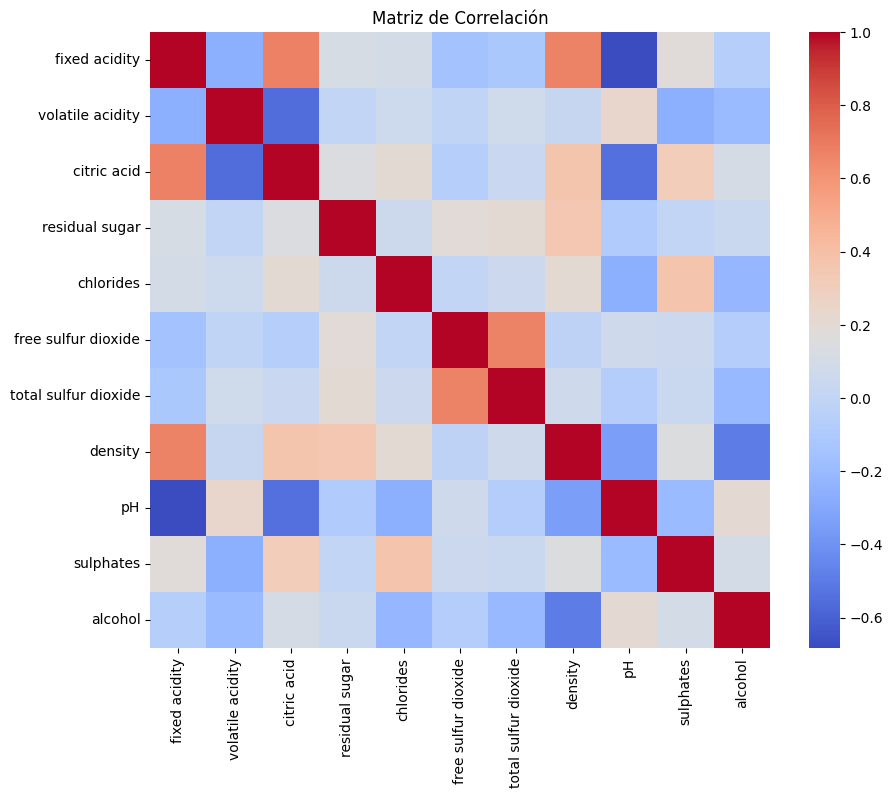

In [7]:
# 2. Calculo matriz de correlaciones
matriz_corr = df_zscore.corr()

plt.figure(figsize=(10, 8))

# Creamos el mapa de calor
sns.heatmap(matriz_corr, cmap='coolwarm', fmt=".2f")

plt.title("Matriz de Correlación")
# plt.savefig("figuras/var-heatmap.pdf")
plt.show()

A continuación, aplicamos el algoritmo *greedy* para hallar las variables más significativas.

In [8]:
np_corr = matriz_corr.to_numpy()
variables = matriz_corr.columns.tolist()
ord_var_ind, f_ord_var = greedy(lambda S: log_det_var(S, np_corr), n_var, n_var)
ord_var = [variables[i] for i in ord_var_ind]

resultados = [(i+1, ord_var[i], f_ord_var[i]) for i in range(n_var)]
df_orden_variables = pd.DataFrame(resultados, columns=['Puesto', 'Variable', 'Log-det'])
print(df_orden_variables)
# print(df_orden_variables.to_latex(index=False, 
#                         formatters={'Log-det': "{:,.4f}".format}, # 4 decimales
#                         column_format='clr', # c=center, l=left, r=right
#                         caption="Progreso del log-determinante según la variable seleccionada."))

    Puesto              Variable   Log-det
0        1         fixed acidity  0.000000
1        2               alcohol -0.003810
2        3        residual sugar -0.019532
3        4             sulphates -0.065541
4        5   free sulfur dioxide -0.152251
5        6      volatile acidity -0.322655
6        7             chlorides -0.576486
7        8  total sulfur dioxide -1.238686
8        9                    pH -2.043620
9       10           citric acid -3.183947
10      11               density -5.031419


## 4.3. Selección de observaciones

### Selección de las $m$ observaciones influyentes.

Se ha utilizado el algoritmo greedy para resolver el problema. Se ha fijado el
hiperparámetro $m = 100$, con el fin de seleccionar las $100$ observaciones más informativas,
o dicho de otro modo, las $100$ botellas de vino con mayor dispersión observada en sus
características.

In [9]:
m_obs = 100 # Observaciones que se quieren seleccionar

In [10]:
# 1. Añadimos una columna de unos a la matriz X.
xxt = [np.outer(X_aum[i,:], X_aum[i,:]) for i in range(n_obs)] # Productos externos
ord_obs_ind, f_ord_obs = lazy_greedy(lambda S: np.log(np.linalg.det(np.eye(n_var+1)+sum(xxt[i] for i in S))), n_obs, m_obs)

La siguiente tabla muestra el valor del log determinante en cada iteración (se muestran las primeras y las últimas).

In [11]:
df_observaciones = pd.DataFrame({
    "Obervación": [0] + ord_obs_ind,
    "Log_determinante": [0] + f_ord_obs,
})
df_observaciones

,Obervación,Log_determinante
0,0,0.000000
1,151,5.404032
2,1434,10.103150
3,1081,14.438427
4,92,18.194826
...,...,...
96,608,62.708783
97,1186,62.802249
98,1372,62.894889
99,1233,62.986636


### Scatter de las observaciones influyentes frente a las demás

También podemos ver cómo se distribuyen estas observaciones influyentes entre todas las observaciones incluidas, para ver si se han escogido valores con dispersión adecuada o no.

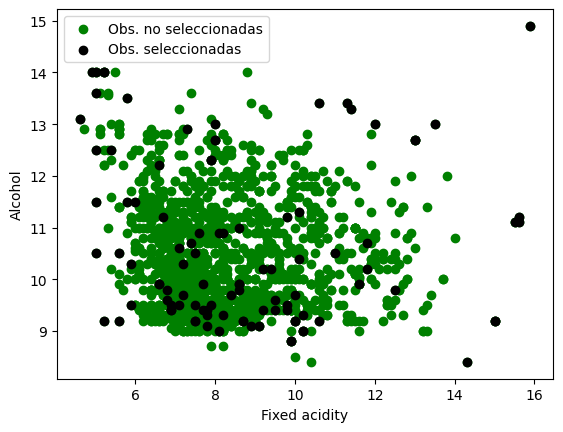

In [12]:
X_red = X_bruta[:,[ord_var_ind[0],ord_var_ind[1]]]
X_red_doptimo = X_red[ord_obs_ind]

plt.figure()

plt.scatter(X_red[:,0],X_red[:,1], color='g')
plt.scatter(X_red_doptimo[:,0],X_red_doptimo[:,1],  color='k')
plt.xlabel("Fixed acidity")
plt.ylabel("Alcohol")
plt.legend(["Obs. no seleccionadas", "Obs. seleccionadas"])
#plt.savefig("figuras/VP-observaciones_seleccionadas.pdf")
plt.show()


Como se puede apreciar, las observaciones atípicas tienden a ser seleccionadas, enten-
diendo como atípico a lo alejado de la media. Esto puede generar problemas en el método
a través de los outliers. Por tanto, se debe hacer una detección previa de observaciones
atípicas antes de comenzar con la selección de variables.

### III. Comparativa greedy - lazy greedy

Sabemos que el algoritmo _greedy_ y _lazy greedy_ producen la misma solución. En este apartado discutiremos la diferencia entre la eficiencia de ambos algoritmos.

#### Comparación en tiempo.

In [13]:
t0 = perf_counter()
greedy(lambda S: np.log(np.linalg.det(np.eye(12)+sum(xxt[i] for i in S))), n_obs, 100)
t1 = perf_counter()
print("Tiempo del algoritmo greedy:", t1-t0)
t0 = perf_counter()
lazy_greedy(lambda S: np.log(np.linalg.det(np.eye(12)+sum(xxt[i] for i in S))), n_obs, 100)
t1 = perf_counter()
print("Tiempo del algoritmo lazy greedy:", t1-t0)

Tiempo del algoritmo greedy: 1.913357375000487
Tiempo del algoritmo lazy greedy: 0.09535945799871115


#### Comparación en número de ejecuciones.

In [14]:
evaluaciones_greedy = np.zeros(m_obs, dtype=int)
evaluaciones_lazy = np.zeros(m_obs, dtype=int)

def f_greedy(S):
    len_S = len(S)
    evaluaciones_greedy[len_S-1] += 1
    return np.log(np.linalg.det(np.eye(n_var+1)+sum(xxt[i] for i in S)))

def f_lazy(S):
    len_S = len(S)
    if len_S>0:
        evaluaciones_lazy[len_S-1] += 1
    return np.log(np.linalg.det(np.eye(n_var+1)+sum(xxt[i] for i in S)))

greedy(f_greedy, n_obs, m_obs)
lazy_greedy(f_lazy, n_obs, m_obs)
cum_evaluaciones_greedy = np.cumsum(evaluaciones_greedy)
cum_evaluaciones_lazy = np.cumsum(evaluaciones_lazy)



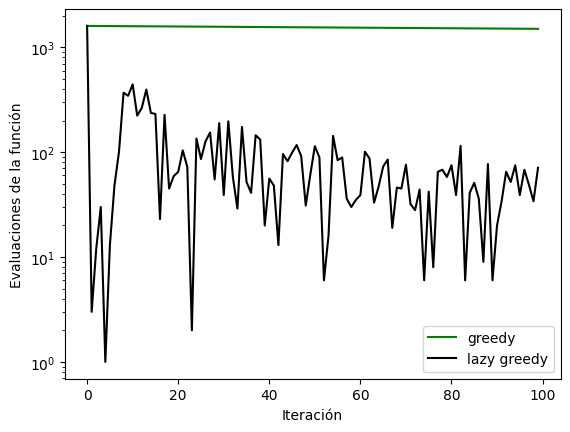

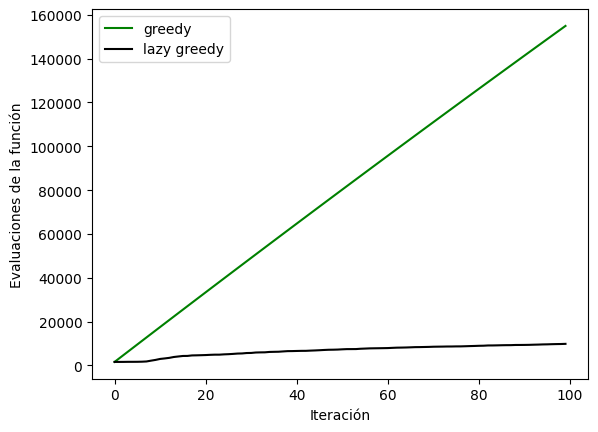

In [15]:
plt.figure()
plt.plot(evaluaciones_greedy, color='g')
plt.plot(evaluaciones_lazy, color='k')
plt.xlabel("Iteración")
plt.ylabel("Evaluaciones de la función")
plt.legend(['greedy', 'lazy greedy'])
plt.yscale('log')
# plt.savefig('figuras/comparacion_greedy_lazy.pdf') # 
plt.show()

plt.figure()
plt.plot(cum_evaluaciones_greedy, color='g')
plt.plot(cum_evaluaciones_lazy, color='k')
plt.xlabel("Iteración")
plt.ylabel("Evaluaciones de la función")
plt.legend(['greedy', 'lazy greedy'])
# plt.savefig('figuras/cum_comparacion_greedy_lazy.pdf')
#plt.yscale('log')
plt.show()

Se puede apreciar que la diferencia de rendimiento entre los dos algoritmos es de más de un orden de magnitud, por lo que la mejora es muy significativa.